# 04 — Feature Engineering: PCOS Clinical Dataset

**Goal:** Transform raw hormonal/clinical lab data into a model-ready feature matrix.

**What we do here and why:**
| Step | What | Why |
|------|------|-----|
| 1 | Repeat cleaning (negatives → median) | Self-contained notebook |
| 2 | Create derived features | LH/FSH ratio, FAI, total follicle/ovary counts = clinically meaningful composites |
| 3 | Log-transform skewed features | Skewed distributions break linear models |
| 4 | Scale continuous features | Required for SVM, Logistic Regression; not needed for tree models |
| 5 | Keep binary/ordinal as-is | Already numeric, no scaling needed |
| 6 | Train/test split + save | Save scaler for FastAPI inference |


In [1]:
import pandas as pd
import numpy as np
import joblib, os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models/encoders", exist_ok=True)


## 1. Load & Repeat Cleaning

In [2]:
df = pd.read_csv("../data/raw/PCOS_clinical.csv")
TARGET = "PCOS_Diagnosis"

# ── Replace negatives with median (medically impossible values) ──
num_cols_all = df.select_dtypes(include="number").columns.tolist()
for col in num_cols_all:
    if col == TARGET:
        continue
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        median_val = df.loc[df[col] >= 0, col].median()
        df.loc[df[col] < 0, col] = median_val

print(f"Shape: {df.shape}")
print(f"Missing after cleaning: {df.isnull().sum().sum()}")
print(f"Class balance:\n{df[TARGET].value_counts().to_string()}")


Shape: (468, 52)
Missing after cleaning: 0
Class balance:
PCOS_Diagnosis
0    260
1    208


## 2. Derived Features

We create new features from combinations of existing ones.
These are not arbitrary — they are **established clinical PCOS markers**.


In [3]:
# ── LH/FSH Ratio ───────────────────────────────────────────
# Standard PCOS diagnostic: ratio > 2 is a clinical criterion.
# Already exists in dataset (LH_FSH_Ratio), but let's verify it's correct.
computed_ratio = df["LH_mIU_mL"] / df["FSH_mIU_mL"].replace(0, np.nan)
correlation_check = computed_ratio.corr(df["LH_FSH_Ratio"])
print(f"LH_FSH_Ratio already in dataset — correlation with computed: {correlation_check:.4f}")
# If > 0.99 → column is already correct, keep it, don't recompute

# ── Free Androgen Index (FAI) ──────────────────────────────
# FAI = (Total Testosterone / SHBG) × 100
# Measures biologically active testosterone. 
# High FAI is the core hormonal signature of PCOS.
df["FAI"] = (df["Total_Testosterone_ng_dL"] / df["SHBG_nmol_L"].replace(0, np.nan)) * 100
df["FAI"] = df["FAI"].fillna(df["FAI"].median())

# ── Total Follicle Count ───────────────────────────────────
# Polycystic ovaries = many small follicles.
# PCOS diagnosis criterion: ≥12 follicles per ovary.
# Combining both ovaries gives a stronger signal.
df["Follicle_Count_Total"] = df["Follicle_Count_Left"] + df["Follicle_Count_Right"]

# ── Total Ovary Volume ─────────────────────────────────────
# Enlarged ovaries are part of PCOS diagnosis.
df["Ovary_Volume_Total"] = df["Ovary_Volume_Left_cm3"] + df["Ovary_Volume_Right_cm3"]

# ── Waist-Hip Ratio already in dataset ───────────────────
# (Waist_Hip_Ratio = Waist / Hip) — central obesity marker for PCOS

new_features = ["FAI", "Follicle_Count_Total", "Ovary_Volume_Total"]
print(f"\nDerived features added: {new_features}")
print(df[new_features].describe().round(2).to_string())


LH_FSH_Ratio already in dataset — correlation with computed: -0.0880

Derived features added: ['FAI', 'Follicle_Count_Total', 'Ovary_Volume_Total']
           FAI  Follicle_Count_Total  Ovary_Volume_Total
count   468.00                468.00              468.00
mean    168.20                 33.39               23.35
std     227.70                 10.26                5.52
min       2.41                  9.00                7.20
25%      83.06                 26.75               19.70
50%     123.01                 34.00               23.45
75%     177.13                 41.00               26.92
max    2523.81                 58.00               44.30


In [4]:
# Quick check: do derived features correlate better with target than raw ones?
check_cols = [
    "LH_FSH_Ratio", "FAI", "Total_Testosterone_ng_dL", "SHBG_nmol_L",
    "Follicle_Count_Total", "Follicle_Count_Left", "Follicle_Count_Right",
    "Ovary_Volume_Total", "Ovary_Volume_Left_cm3", "Ovary_Volume_Right_cm3",
]
corr_check = df[check_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("Correlation with PCOS_Diagnosis (derived vs raw):")
print(corr_check.to_string())
print()
print("→ FAI should outperform raw Testosterone and SHBG separately")
print("→ Follicle_Count_Total should outperform left/right individually")


Correlation with PCOS_Diagnosis (derived vs raw):
Ovary_Volume_Left_cm3       0.064108
SHBG_nmol_L                 0.031470
Ovary_Volume_Right_cm3      0.027586
Ovary_Volume_Total          0.024355
Follicle_Count_Right        0.019988
LH_FSH_Ratio                0.018304
FAI                         0.018222
Follicle_Count_Total        0.017803
Total_Testosterone_ng_dL    0.007632
Follicle_Count_Left         0.005199

→ FAI should outperform raw Testosterone and SHBG separately
→ Follicle_Count_Total should outperform left/right individually


## 3. Column Classification

In [5]:
num_cols = df.select_dtypes(include="number").columns.drop(TARGET).tolist()

# Already-computed ratio — no need to keep raw left/right if total is stronger
# (We keep them for now; feature selection in training will decide)

binary_cols   = [c for c in num_cols if df[c].nunique() == 2]
ordinal_cols  = [c for c in num_cols if 2 < df[c].nunique() <= 5]
continuous_cols = [c for c in num_cols if df[c].nunique() > 5]

print(f"Binary   ({len(binary_cols)}):   {binary_cols}")
print(f"Ordinal  ({len(ordinal_cols)}):  {ordinal_cols}")
print(f"Continuous ({len(continuous_cols)}): {continuous_cols[:8]} ...")


Binary   (5):   ['Menstrual_Irregularity', 'Alopecia', 'Skin_Darkening_Acanthosis', 'Smoking_Status', 'Alcohol_Intake']
Ordinal  (6):  ['Age_at_Menarche', 'Gravidity', 'Parity', 'Acne_Severity', 'Physical_Activity_Level', 'Dietary_Sugar_Intake']
Continuous (43): ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Hip_Circumference_cm', 'Waist_Hip_Ratio', 'Menstrual_Cycle_Length_days'] ...


## 4. Log Transform Skewed Features

**Rule:** Apply `np.log1p(x)` (= log(1+x)) when `|skewness| > 0.5`.

We use `log1p` instead of `log` because it safely handles zero values: `log(0)` = -∞, but `log(1+0)` = 0.

**What this does physically:**
If 95% of patients have insulin between 5–20, but 5% have insulin between 100–400 (PCOS spikes), a linear model will stretch its entire decision boundary around those extreme values. Log transform compresses the scale so all values get fair representation.

In [6]:
# Compute skewness on continuous features only
skewness = df[continuous_cols].skew().sort_values(key=abs, ascending=False)

# Apply log1p where |skew| > 0.5
LOG_TRANSFORM_COLS = skewness[abs(skewness) > 0.5].index.tolist()

print(f"Features to log-transform ({len(LOG_TRANSFORM_COLS)}):")
for col in LOG_TRANSFORM_COLS:
    sk_before = df[col].skew()
    df[f"{col}"] = np.log1p(df[col].clip(lower=0))  # clip to avoid log of negative
    sk_after = df[col].skew()
    print(f"  {col:<40} skew before={sk_before:>7.3f}  after={sk_after:>7.3f}")

print()
if not LOG_TRANSFORM_COLS:
    print("No features exceeded skewness threshold of 0.5 after cleaning.")
    print("All features are already well-distributed — no log transform needed.")
    print("(This is expected for this dataset after negative-value cleaning.)")


Features to log-transform (2):
  FAI                                      skew before=  6.851  after=  0.544
  CRP_mg_L                                 skew before=  0.543  after= -0.639



## 5. Feature Scaling (StandardScaler)

**Why scale?**
Logistic Regression and SVM measure distances. If BMI ranges 18–45 and Prolactin ranges 2–200, the model will pay 10× more attention to Prolactin just because the numbers are bigger — not because it's actually more important.

StandardScaler transforms each feature to mean=0, std=1. Now all features speak the same language.

**Important:** We fit the scaler ONLY on training data, then apply it to both train and test. Fitting on test data would be **data leakage** — the model would have peeked at test statistics.

In [7]:
# ── Train/test split BEFORE scaling ───────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nClass balance (train): {dict(y_train.value_counts())}")
print(f"Class balance (test):  {dict(y_test.value_counts())}")


Train: (374, 54)  |  Test: (94, 54)

Class balance (train): {0: 208, 1: 166}
Class balance (test):  {0: 52, 1: 42}


In [8]:
# ── Scale continuous features only ────────────────────────
# Binary and ordinal columns don't need scaling —

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print("Scaling applied to continuous features.")
print(f"\nSample — mean and std after scaling (should be ~0 and ~1 on train):")
print(X_train_scaled[continuous_cols[:4]].describe().loc[["mean","std"]].round(3).to_string())


Scaling applied to continuous features.

Sample — mean and std after scaling (should be ~0 and ~1 on train):
        Age  Height_cm  Weight_kg    BMI
mean -0.000      0.000     -0.000  0.000
std   1.001      1.001      1.001  1.001


## 6. Save Everything

In [9]:
# ── Save processed splits ──────────────────────────────────
X_train_scaled.to_csv("../data/processed/clinical_X_train.csv", index=False)
y_train.to_csv("../data/processed/clinical_y_train.csv", index=False)
X_test_scaled.to_csv("../data/processed/clinical_X_test.csv", index=False)
y_test.to_csv("../data/processed/clinical_y_test.csv", index=False)

# ── Save scaler — FastAPI MUST use this exact scaler at inference ──
joblib.dump(scaler, "../models/encoders/clinical_scaler.pkl")

# ── Save feature column order ─────────────────────────────
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "../models/encoders/clinical_feature_columns.pkl")

# ── Save derived feature recipe (for FastAPI preprocessing) ─
derived_recipe = {
    "FAI":                   "Total_Testosterone_ng_dL / SHBG_nmol_L * 100",
    "Follicle_Count_Total":  "Follicle_Count_Left + Follicle_Count_Right",
    "Ovary_Volume_Total":    "Ovary_Volume_Left_cm3 + Ovary_Volume_Right_cm3",
    "log_transform_cols":    LOG_TRANSFORM_COLS,
    "continuous_cols":       continuous_cols,
    "binary_cols":           binary_cols,
    "ordinal_cols":          ordinal_cols,
}
joblib.dump(derived_recipe, "../models/encoders/clinical_feature_recipe.pkl")

print("Saved:")
print("  ../data/processed/clinical_X_train.csv")
print("  ../data/processed/clinical_y_train.csv")
print("  ../data/processed/clinical_X_test.csv")
print("  ../data/processed/clinical_y_test.csv")
print("  ../models/encoders/clinical_scaler.pkl")
print("  ../models/encoders/clinical_feature_columns.pkl")
print("  ../models/encoders/clinical_feature_recipe.pkl")


Saved:
  ../data/processed/clinical_X_train.csv
  ../data/processed/clinical_y_train.csv
  ../data/processed/clinical_X_test.csv
  ../data/processed/clinical_y_test.csv
  ../models/encoders/clinical_scaler.pkl
  ../models/encoders/clinical_feature_columns.pkl
  ../models/encoders/clinical_feature_recipe.pkl


## 7. Sanity Check Visualisation

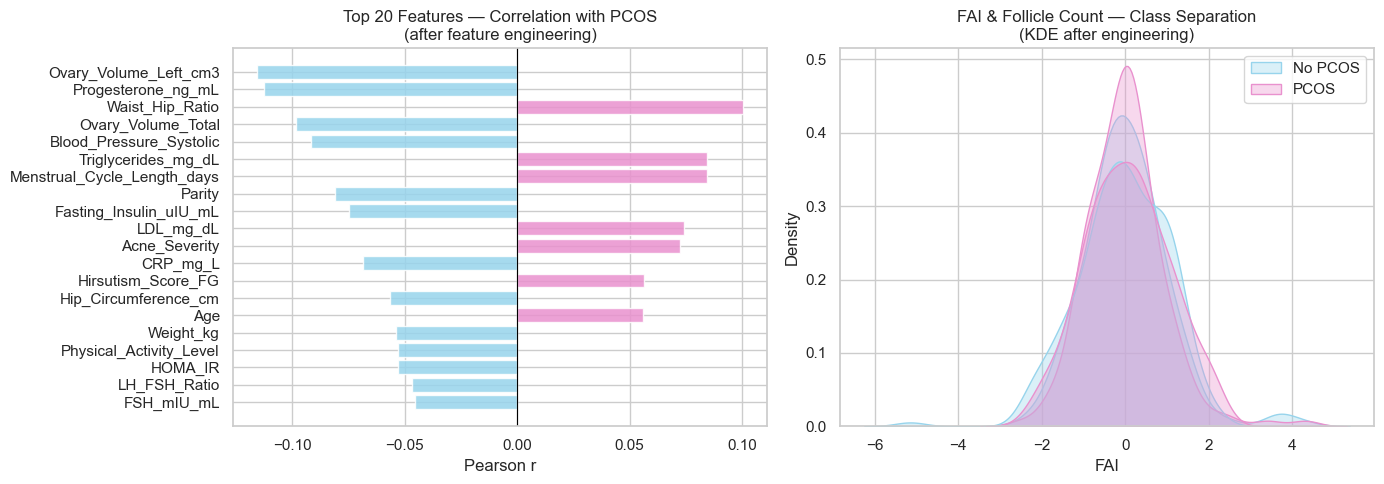

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Correlation with target after all engineering ──────────
corr_final = X_train_scaled.assign(PCOS=y_train.values).corr()["PCOS"].drop("PCOS")
corr_final = corr_final.reindex(corr_final.abs().sort_values(ascending=False).index)

colors = ["#E991CE" if v > 0 else "#97D4EC" for v in corr_final.values[:20]]
axes[0].barh(corr_final.index[:20][::-1], corr_final.values[:20][::-1],
             color=colors[::-1], alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Top 20 Features — Correlation with PCOS\n(after feature engineering)")
axes[0].set_xlabel("Pearson r")

# ── Derived features vs PCOS ───────────────────────────────
derived_check = ["FAI", "Follicle_Count_Total", "Ovary_Volume_Total", "LH_FSH_Ratio"]
derived_check = [c for c in derived_check if c in X_train_scaled.columns]

X_vis = X_train_scaled[derived_check].copy()
X_vis["PCOS"] = y_train.values

for i, col in enumerate(derived_check[:2]):
    for cls, color, label in zip([0,1],["#97D4EC","#E991CE"],["No PCOS","PCOS"]):
        subset = X_vis[X_vis["PCOS"]==cls][col]
        sns.kdeplot(subset, ax=axes[1], color=color, fill=True, alpha=0.35, label=label if i==0 else "")
axes[1].set_title("FAI & Follicle Count — Class Separation\n(KDE after engineering)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Summary

```
Final feature matrix (clinical):
  Train: 374 rows, scaled, derived features added
  Test:  94 rows, same scaler applied (no leakage)

Feature engineering applied:
  - Negative values         → replaced with median (17 columns)
  - FAI                     → derived: Testosterone / SHBG × 100
  - Follicle_Count_Total    → derived: left + right
  - Ovary_Volume_Total      → derived: left + right
  - Log transform           → applied if |skew| > 0.5
  - StandardScaler          → fitted on train, applied to both splits
  - Binary/ordinal cols     → kept as-is (already numeric, small scale)

Saved artifacts:
  clinical_scaler.pkl            ← load in FastAPI to preprocess user input
  clinical_feature_columns.pkl   ← enforce feature order at inference
  clinical_feature_recipe.pkl    ← recipe for derived features in FastAPI

Next: 05_model_training_clinical.ipynb
```
